<a href="https://colab.research.google.com/github/nikhilRajput-prog/Deep-Learning-Lab-File/blob/main/Deep_Learning_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install (usually pre-installed in Colab, but safe to run)
!pip install torch torchvision matplotlib

# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = torchvision.datasets.FashionMNIST(
    root='./data', train=True, transform=transform, download=True)

test_data = torchvision.datasets.FashionMNIST(
    root='./data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=128, shuffle=False)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

Training samples: 60000
Testing samples: 10000


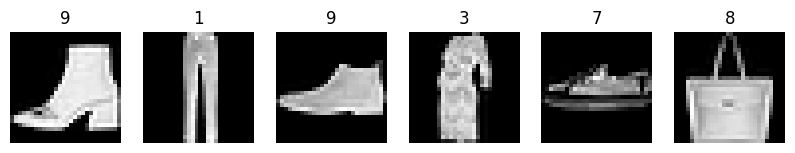

In [ ]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

fig, axes = plt.subplots(1, 6, figsize=(10,2))
for i in range(6):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(labels[i].item())
    axes[i].axis('off')

plt.show()

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

autoencoder = Autoencoder().to(device)
print(autoencoder)

Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


In [ ]:
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 50

for epoch in range(epochs):
    total_loss = 0

    for img, _ in train_loader:
        img = img.to(device)

        output = autoencoder(img)
        loss = loss_fn(output, img.view(-1, 28*28))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 16.9263
Epoch 2, Loss: 8.9540
Epoch 3, Loss: 7.6539
Epoch 4, Loss: 6.8092
Epoch 5, Loss: 6.2996
Epoch 6, Loss: 5.9306
Epoch 7, Loss: 5.6459
Epoch 8, Loss: 5.3990
Epoch 9, Loss: 5.1991
Epoch 10, Loss: 5.0288
Epoch 11, Loss: 4.8867
Epoch 12, Loss: 4.7594
Epoch 13, Loss: 4.6447
Epoch 14, Loss: 4.5404
Epoch 15, Loss: 4.4514
Epoch 16, Loss: 4.3681
Epoch 17, Loss: 4.2921
Epoch 18, Loss: 4.2260
Epoch 19, Loss: 4.1621
Epoch 20, Loss: 4.1048
Epoch 21, Loss: 4.0546
Epoch 22, Loss: 4.0013
Epoch 23, Loss: 3.9541
Epoch 24, Loss: 3.9115
Epoch 25, Loss: 3.8705
Epoch 26, Loss: 3.8342
Epoch 27, Loss: 3.7964
Epoch 28, Loss: 3.7678
Epoch 29, Loss: 3.7347
Epoch 30, Loss: 3.7049
Epoch 31, Loss: 3.6738
Epoch 32, Loss: 3.6452
Epoch 33, Loss: 3.6220
Epoch 34, Loss: 3.5985
Epoch 35, Loss: 3.5757
Epoch 36, Loss: 3.5537
Epoch 37, Loss: 3.5381
Epoch 38, Loss: 3.5185
Epoch 39, Loss: 3.4995
Epoch 40, Loss: 3.4876
Epoch 41, Loss: 3.4719
Epoch 42, Loss: 3.4585
Epoch 43, Loss: 3.4440
Epoch 44, Loss: 3.4

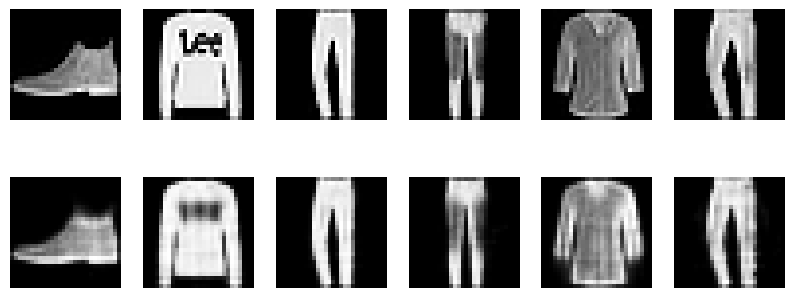

In [ ]:
autoencoder.eval()

with torch.no_grad():
    img, _ = next(iter(test_loader))
    img = img.to(device)

    output = autoencoder(img)

    fig, axes = plt.subplots(2, 6, figsize=(10,4))

    for i in range(6):
        # Original
        axes[0,i].imshow(img[i].cpu().squeeze(), cmap='gray')
        axes[0,i].axis('off')

        # Reconstructed
        axes[1,i].imshow(output[i].cpu().view(28,28), cmap='gray')
        axes[1,i].axis('off')

plt.show()

In [ ]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(28*28, 128)
        self.fc_mu = nn.Linear(128, 20)
        self.fc_logvar = nn.Linear(128, 20)

        self.fc2 = nn.Linear(20, 128)
        self.fc3 = nn.Linear(128, 28*28)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        x = x.view(-1, 28*28)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

vae = VAE().to(device)
print(vae)

VAE(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc_mu): Linear(in_features=128, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=784, bias=True)
)


In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(
        recon_x, x.view(-1, 28*28), reduction='mean')

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return (BCE + KLD) / x.size(0)

In [ ]:
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

epochs = 30

for epoch in range(epochs):
    total_loss = 0

    for img, _ in train_loader:
        img = img.to(device)

        recon, mu, logvar = vae(img)
        loss = vae_loss(recon, img, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 1.8001
Epoch 2, Loss: 1.7993
Epoch 3, Loss: 1.7991
Epoch 4, Loss: 1.7989
Epoch 5, Loss: 1.7988
Epoch 6, Loss: 1.7986
Epoch 7, Loss: 1.7986
Epoch 8, Loss: 1.7987
Epoch 9, Loss: 1.7986
Epoch 10, Loss: 1.7984
Epoch 11, Loss: 1.7983
Epoch 12, Loss: 1.7984
Epoch 13, Loss: 1.7984
Epoch 14, Loss: 1.7983
Epoch 15, Loss: 1.7983
Epoch 16, Loss: 1.7984
Epoch 17, Loss: 1.7983
Epoch 18, Loss: 1.7982
Epoch 19, Loss: 1.7983
Epoch 20, Loss: 1.7982
Epoch 21, Loss: 1.7983
Epoch 22, Loss: 1.7981
Epoch 23, Loss: 1.7981
Epoch 24, Loss: 1.7981
Epoch 25, Loss: 1.7981
Epoch 26, Loss: 1.7983
Epoch 27, Loss: 1.7981
Epoch 28, Loss: 1.7981
Epoch 29, Loss: 1.7981
Epoch 30, Loss: 1.7982


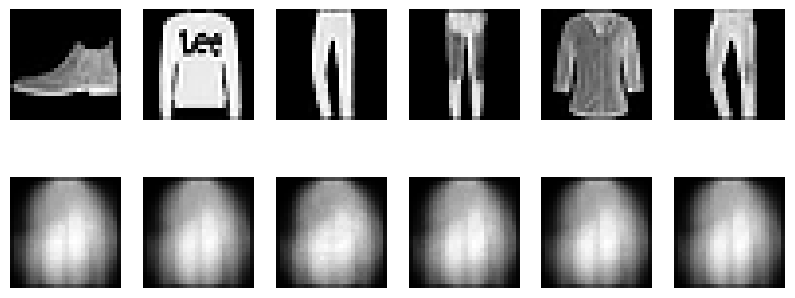

In [ ]:
vae.eval()

with torch.no_grad():
    img, _ = next(iter(test_loader))
    img = img.to(device)

    recon, _, _ = vae(img)

    fig, axes = plt.subplots(2, 6, figsize=(10,4))

    for i in range(6):
        axes[0,i].imshow(img[i].cpu().squeeze(), cmap='gray')
        axes[0,i].axis('off')

        axes[1,i].imshow(recon[i].cpu().view(28,28), cmap='gray')
        axes[1,i].axis('off')

plt.show()

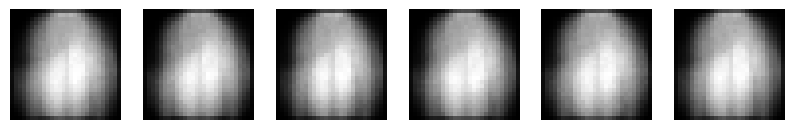

In [ ]:
with torch.no_grad():
    z = torch.randn(6, 20).to(device)
    samples = vae.decode(z)

    fig, axes = plt.subplots(1, 6, figsize=(10,2))

    for i in range(6):
        axes[i].imshow(samples[i].cpu().view(28,28), cmap='gray')
        axes[i].axis('off')

plt.show()